# 05 - Salinas CNN Training

Goal: train the first real labeled model on the Salinas hyperspectral benchmark. This turns the project from shape validation into accuracy/F1 evaluation.

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch import nn
from torch.utils.data import DataLoader
from tqdm.auto import tqdm

from dfm.data.salinas import (
    SALINAS_CLASS_NAMES,
    SalinasPatchDataset,
    labeled_pixel_indices,
    load_salinas,
    stratified_train_test_split,
)
from dfm.models.cnn_baseline import CNNBaseline
from dfm.training.metrics import accuracy_score, macro_f1_score
from dfm.training.profiling import count_parameters

c:\Users\Dines\Documents\Codex\2026-05-15\files-mentioned-by-the-user-dataset0\dense-forest-monitoring\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

data_dir = PROJECT_ROOT / "data" / "raw" / "salinas"
scene = load_salinas(data_dir, download=True)

print("Cube shape (H, W, C):", scene.cube.shape)
print("Label map shape:", scene.labels.shape)
print("Bands:", scene.bands)
print("Classes:", len(scene.class_names))

Cube shape (H, W, C): (512, 217, 204)
Label map shape: (512, 217)
Bands: 204
Classes: 16


In [4]:
rows, cols, labels = labeled_pixel_indices(scene.labels)
class_counts = pd.Series(labels).value_counts().sort_index()
class_table = pd.DataFrame({
    "class_id": np.arange(1, len(SALINAS_CLASS_NAMES) + 1),
    "class_name": SALINAS_CLASS_NAMES,
    "samples": [int(class_counts.get(i, 0)) for i in range(len(SALINAS_CLASS_NAMES))],
})
class_table

,class_id,class_name,samples
0,1,Brocoli_green_weeds_1,2009
1,2,Brocoli_green_weeds_2,3726
2,3,Fallow,1976
3,4,Fallow_rough_plow,1394
4,5,Fallow_smooth,2678
5,6,Stubble,3959
6,7,Celery,3579
7,8,Grapes_untrained,11271
8,9,Soil_vinyard_develop,6203
9,10,Corn_senesced_green_weeds,3278


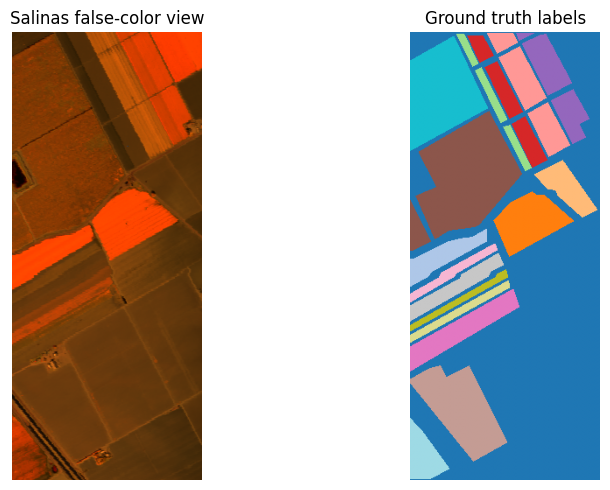

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

false_rgb = scene.cube[:, :, [50, 100, 150]].astype(np.float32)
low, high = np.percentile(false_rgb, [2, 98])
false_rgb = np.clip((false_rgb - low) / (high - low), 0, 1)

axes[0].imshow(false_rgb)
axes[0].set_title("Salinas false-color view")
axes[0].axis("off")

axes[1].imshow(scene.labels, cmap="tab20")
axes[1].set_title("Ground truth labels")
axes[1].axis("off")

plt.tight_layout();

In [6]:
train_indices, test_indices = stratified_train_test_split(labels, train_fraction=0.1, seed=SEED)

patch_size = 15
train_dataset = SalinasPatchDataset(scene, indices=train_indices, patch_size=patch_size)
test_dataset = SalinasPatchDataset(scene, indices=test_indices, patch_size=patch_size)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=0)

print("Train samples:", len(train_dataset))
print("Test samples:", len(test_dataset))
sample_x, sample_y = train_dataset[0]
print("Sample patch:", sample_x.shape, "label:", sample_y)

Train samples: 5415
Test samples: 48714
Sample patch: (204, 15, 15) label: 8


In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNNBaseline(
    in_channels=scene.bands,
    num_classes=len(SALINAS_CLASS_NAMES),
    hidden_channels=64,
    dropout=0.1,
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-4)

print("Device:", device)
print("Trainable parameters:", count_parameters(model))

Device: cpu
Trainable parameters: 126480


In [8]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0.0
    total = 0
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        y = y.to(device=device, dtype=torch.long)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += float(loss.item()) * x.shape[0]
        total += x.shape[0]
    return total_loss / total


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    all_true = []
    all_pred = []
    for x, y in tqdm(loader, leave=False):
        x = x.to(device=device, dtype=torch.float32)
        logits = model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_pred.append(pred)
        all_true.append(y.numpy())

    y_true = np.concatenate(all_true)
    y_pred = np.concatenate(all_pred)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_f1": macro_f1_score(y_true, y_pred, num_classes=len(SALINAS_CLASS_NAMES)),
    }

In [9]:
history = []
epochs = 5
best_macro_f1 = -1.0
best_state = None
best_epoch = None

for epoch in range(1, epochs + 1):
    train_loss = train_one_epoch(model, train_loader)
    metrics = evaluate(model, test_loader)
    row = {"epoch": epoch, "train_loss": train_loss, **metrics}
    history.append(row)

    if metrics["macro_f1"] > best_macro_f1:
        best_macro_f1 = metrics["macro_f1"]
        best_epoch = epoch
        best_state = {key: value.detach().cpu().clone() for key, value in model.state_dict().items()}

    print(row)

history_df = pd.DataFrame(history)
print(f"Best epoch by macro-F1: {best_epoch} ({best_macro_f1:.4f})")
history_df

{'epoch': 1, 'train_loss': 1.040814020142771, 'accuracy': 0.727306318512132, 'macro_f1': 0.7118924096782424}


{'epoch': 2, 'train_loss': 0.4025786363572185, 'accuracy': 0.9294453339902287, 'macro_f1': 0.9095435885920831}


{'epoch': 3, 'train_loss': 0.23583631440653144, 'accuracy': 0.9012193619903929, 'macro_f1': 0.9497376309534468}


{'epoch': 4, 'train_loss': 0.17022539626528352, 'accuracy': 0.9482489633370283, 'macro_f1': 0.9743759630093204}


{'epoch': 5, 'train_loss': 0.15491041062281072, 'accuracy': 0.7959724103953689, 'macro_f1': 0.9086066041142973}


,epoch,train_loss,accuracy,macro_f1
0,1,1.040814,0.727306,0.711892
1,2,0.402579,0.929445,0.909544
2,3,0.235836,0.901219,0.949738
3,4,0.170225,0.948249,0.974376
4,5,0.154910,0.795972,0.908607


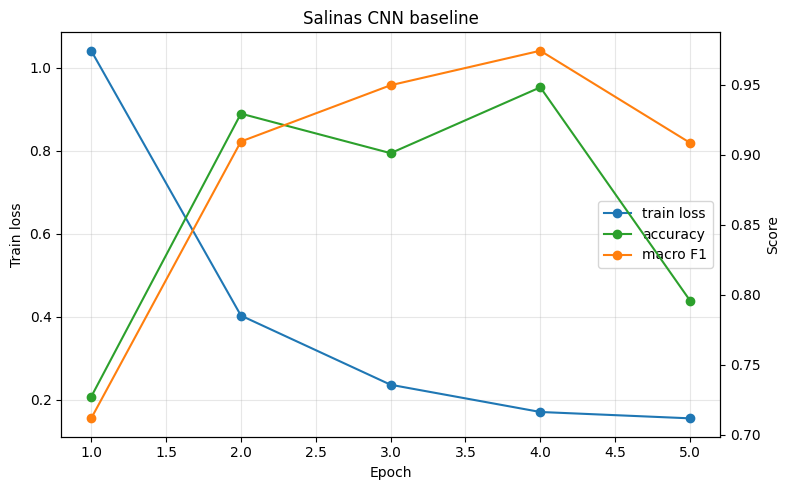

In [10]:
outputs_dir = PROJECT_ROOT / "outputs" / "salinas"
outputs_dir.mkdir(parents=True, exist_ok=True)

history_df.to_csv(outputs_dir / "cnn_baseline_history.csv", index=False)
if best_state is not None:
    torch.save(
        {
            "model_state_dict": best_state,
            "best_epoch": best_epoch,
            "best_macro_f1": best_macro_f1,
            "class_names": SALINAS_CLASS_NAMES,
            "patch_size": patch_size,
            "bands": scene.bands,
        },
        outputs_dir / "cnn_baseline_best.pt",
    )

fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Train loss")
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(history_df["epoch"], history_df["accuracy"], marker="o", color="tab:green", label="accuracy")
ax2.plot(history_df["epoch"], history_df["macro_f1"], marker="o", color="tab:orange", label="macro F1")
if best_epoch is not None:
    ax1.axvline(best_epoch, color="black", linestyle="--", alpha=0.35, label="best epoch")
ax2.set_ylabel("Score")

lines, labels_ = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels_ + labels2, loc="center right")
plt.title("Salinas CNN baseline")
plt.tight_layout()
plt.savefig(outputs_dir / "cnn_baseline_history.png", dpi=200);